In [1]:
import torch.nn as nn

conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
conv

Conv2d(3, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [2]:
conv.weight.shape, conv.bias.shape

(torch.Size([1, 3, 3, 3]), torch.Size([1]))

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

from torchvision import datasets, transforms
data_path = './'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

label_map = {0: 0, 2: 1} # 0 - самолёты, 2 - птицы
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

/home/avtotka/.pyenv/versions/3.14.2/envs/pytorch-learn/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


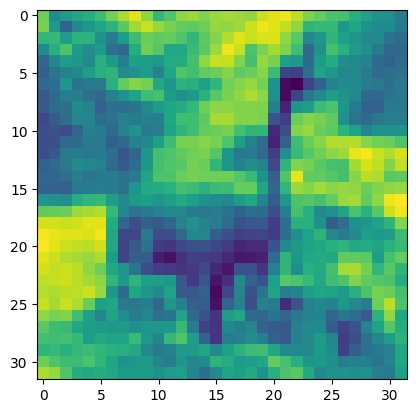

In [4]:
from matplotlib import pyplot as plt

img, _ = cifar2[0]
plt.imshow(img[0])
plt.show()

In [5]:

output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

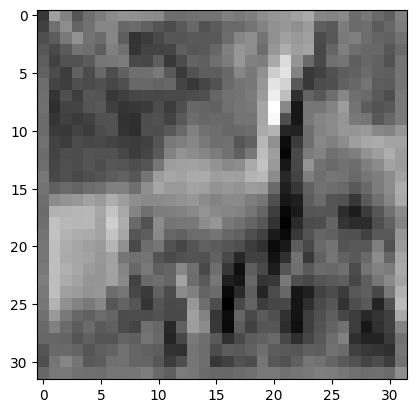

In [6]:
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

Разные ядра

In [7]:
import torch
    
with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1., 0., 1.],
                                   [-1., 0., 1.],
                                   [-1., 0., 1.]])
    conv.bias.zero_()

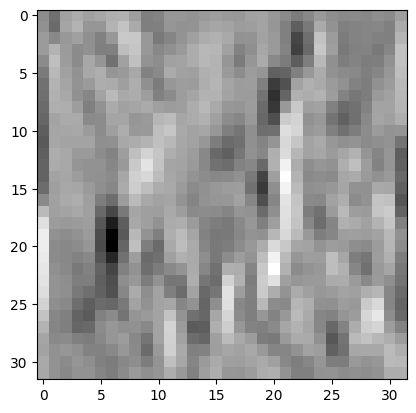

In [8]:
output = conv(img.unsqueeze(0))
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

In [9]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

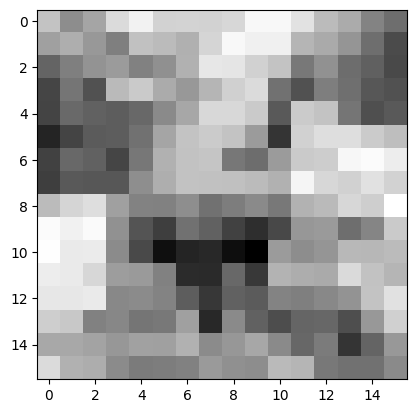

In [10]:
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

Сеть

In [11]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32) # изображение 8x8 с 8 каналами
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8) # изменение формы тензора, чтобы мог пройти в следующий линейный слой
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out   

In [12]:
model = Net()
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [13]:
img, _ = cifar2[0]
model(img.unsqueeze(0))

tensor([[-0.2436, -0.0049]], grad_fn=<AddmmBackward0>)

In [14]:
import datetime

device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))

print(device)

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            # L2-регуляризация (вручную)
            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.).sum for p in model.parameters())
            loss = loss + l2_lambda * l2_norm
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()
            
        if epoch == 1 or epoch % 10 == 0:
            print(f'{datetime.datetime.now()} Epoch {epoch}, Training loss {loss_train / len(train_loader)}')
            

cuda


In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader

train_loader = DataLoader(cifar2, batch_size=64, shuffle=True)
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 300,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader)

2026-04-03 20:56:13.593669 Epoch 1, Training loss 0.5577790805488635
2026-04-03 20:56:17.186583 Epoch 10, Training loss 0.3299190097363891
2026-04-03 20:56:20.871235 Epoch 20, Training loss 0.29686326704397326
2026-04-03 20:56:24.600792 Epoch 30, Training loss 0.26748065565042434
2026-04-03 20:56:28.352709 Epoch 40, Training loss 0.24680148719981976
2026-04-03 20:56:32.104280 Epoch 50, Training loss 0.22846401506548475
2026-04-03 20:56:35.831992 Epoch 60, Training loss 0.2102743915881321
2026-04-03 20:56:39.618199 Epoch 70, Training loss 0.19569300784237065
2026-04-03 20:56:43.356684 Epoch 80, Training loss 0.18168017904090275
2026-04-03 20:56:47.146925 Epoch 90, Training loss 0.1696476112979992
2026-04-03 20:56:50.931410 Epoch 100, Training loss 0.15513675228046003
2026-04-03 20:56:54.664558 Epoch 110, Training loss 0.14347980954464834
2026-04-03 20:56:58.544649 Epoch 120, Training loss 0.13179721002271222
2026-04-03 20:57:02.354966 Epoch 130, Training loss 0.12043741611158772
2026-04

In [16]:
val_loader = DataLoader(cifar2_val, batch_size=64, shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [('train', train_loader), ('val', val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print(f'Accurancy: {name}: {correct/total}')

In [17]:
validate(model, train_loader, val_loader)

Accurancy: train: 0.9987
Accurancy: val: 0.8955


In [18]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')